## 1 Import the CSV data and required packages

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 2 Dropping unnecessary columns

In [ ]:
df.drop(["customerID"],axis=1,inplace=True)
df.drop(["gender"],axis=1,inplace=True)
# The parameter inplace=True modifies the DataFrame df directly instead of creating a new copy.
# No need to assign df = df.drop(...), as the DataFrame is updated in place.

df.shape

(7043, 19)

In [ ]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3 Handling empty strings in a numerical columns

In [ ]:
# TotalCharges often appears as an object (categorical) instead of a float (numerical) because if a customer just joined, that column might have a blank space " " instead of a number. You must convert it to numeric before you start encoding:
# Convert TotalCharges and handle empty strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the resulting NaNs (empty strings) with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

## 4 Set X and Y

In [ ]:
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]
nrows = df.shape[0] # Number of rows in the dataset

print(y.unique())
# Map y to 0 and 1 if it's still 'Yes'/'No'
y = y.map({'Yes': 1, 'No': 0})
print(y.unique())


['No' 'Yes']
[0 1]


## 5 Identify which columns are numeric and which columns are categorical

In [ ]:
# Numerical columns: Everything that is a number
numerical_columns = x.select_dtypes(exclude=["object"]).columns.tolist()

# Categorical columns: Everything that is a string/object
categorical_columns = x.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical: {numerical_columns}")
print(f"Categorical: {categorical_columns}")

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6 Handling the values of categorical columns

In [ ]:
# Create the preprocessing object
preprocessor = ColumnTransformer(
    transformers=[
        ("num_pipeline", StandardScaler(), numerical_columns),
        ("cat_pipeline", OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ]
)

## 7 Training of 8 Models via hyperparameter tuning

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state = 53)

# 2. Transform the data (Encoding + Scaling happen here!)
# This turns strings into numbers AND scales them in one go
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

# Get the feature names if you want to keep track of them
cat_features = preprocessor.named_transformers_['cat_pipeline'].get_feature_names_out()
all_features = numerical_columns + list(cat_features)

# np.random.seed(59) # acts likes random_state without train_test_split sklearn library

# select top 12 most important features using Random Forest
# Feature Selection (Using the transformed numeric data)
rf_temp = RandomForestClassifier(n_estimators=100, random_state=53)
rf_temp.fit(x_train_transformed, y_train)

# Select top features from the transformed array
importances = rf_temp.feature_importances_
indices = importances.argsort()[-12:][::-1] # Indices of top 12 features

# print the selected features
selected_feature_names = [all_features[i] for i in indices]
print("Selected features:", selected_feature_names)

x_train_selected = x_train_transformed[:, indices]
x_test_selected = x_test_transformed[:, indices]  

# 4. Handle Imbalance (SMOTE)
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.5, random_state=53)),
    ('over', RandomOverSampler(sampling_strategy=1, random_state=53))
])

x_resampled, y_resampled = smote_pipeline.fit_resample(x_train_selected, y_train)

# ⚙️ ADJUST THIS VARIABLE TO MATCH YOUR BUSINESS PRIORITIES
# Example: RECALL_WEIGHT = 60  → 60% recall, 40% precision
RECALL_WEIGHT = 50   # (between 0 and 100)

# Calculate the corresponding beta for F-beta score
PRECISION_WEIGHT = 100 - RECALL_WEIGHT
beta = (RECALL_WEIGHT / PRECISION_WEIGHT) ** 0.5

print(f"\n🔧 Custom Scoring Configured:")
print(f"   Recall Weight:    {RECALL_WEIGHT}%")
print(f"   Precision Weight: {PRECISION_WEIGHT}%")
print(f"   Equivalent F-beta (beta = {beta:.3f})")

# Create the scorer
custom_scorer = make_scorer(fbeta_score, beta=beta)

# Define parameter grids for each model
param_grids = {
    "Logistic Regression": {
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=53),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga']
        }
    },
    "Random Forest": {
        'model': RandomForestClassifier(class_weight='balanced', random_state=53, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    "XGBoost": {
        'model': XGBClassifier(scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
                               random_state=53, verbosity=0, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0]
        }
    },
    "LightGBM": {
        'model': LGBMClassifier(class_weight='balanced', random_state=53, verbose=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [31, 50, 100],
            'subsample': [0.7, 0.8, 1.0]
        }
    },
    "CatBoost": {
        'model': CatBoostClassifier(auto_class_weights='Balanced', random_seed=53, verbose=0),
        'params': {
            'iterations': [100, 200, 300],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5]
        }
    },
    "AdaBoost": {
        'model': AdaBoostClassifier(random_state=53),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.5, 1.0]
        }
    },
    "SVM (RBF)": {
        'model': SVC(class_weight='balanced', probability=True, random_state=53),
        'params': {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto', 0.01, 0.1],
            'kernel': ['rbf']
        }
    },
    "K-Neighbors": {
        'model': KNeighborsClassifier(weights='distance'),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'p': [1, 2]   # 1: Manhattan, 2: Euclidean
        }
    }
}

# Store results
tuned_results = []
best_models = {}

print(f"HYPERPARAMETER TUNING FOR ALL MODELS (Scoring = Custom F-beta, beta={beta:.3f})")
print("-"*80)

for name, config in param_grids.items():
    print(f"\n>>> Tuning {name}...")
    
    # Use GridSearchCV for small grids, RandomizedSearchCV for larger ones
    if name in ["XGBoost", "LightGBM", "Random Forest", "CatBoost"]:
        search = RandomizedSearchCV(
            config['model'],
            config['params'],
            n_iter=20,                     # number of random combinations
            scoring=custom_scorer,
            cv=5,
            random_state=53,
            n_jobs=-1,
            verbose=0
        )
    else:
        search = GridSearchCV(
            config['model'],
            config['params'],
            scoring=custom_scorer,
            cv=5,
            n_jobs=-1,
            verbose=0
        )
    
    # Fit on SMOTE-resampled data
    search.fit(x_resampled, y_resampled)
    
    # Best model
    best_model = search.best_estimator_
    best_models[name] = best_model
    
    # Evaluate on test set
    y_pred = best_model.predict(x_test_selected)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    tuned_results.append({
        'Model': name,
        'Best Params': str(search.best_params_),
        'Accuracy': acc,
        'Precision (Churn)': prec,
        'Recall (Churn)': rec,
        'F1 (Churn)': f1
    })
    
    print(f"   Best Recall (CV): {search.best_score_:.4f}")
    print(f"   Test Recall: {rec:.4f}")
    print(f"   Best Params: {search.best_params_}")






Selected features: ['TotalCharges', 'MonthlyCharges', 'tenure', 'Contract_Month-to-month', 'OnlineSecurity_No', 'PaymentMethod_Electronic check', 'TechSupport_No', 'SeniorCitizen', 'InternetService_Fiber optic', 'Contract_Two year', 'OnlineBackup_No', 'PaperlessBilling_Yes']

🔧 Custom Scoring Configured:
   Recall Weight:    50%
   Precision Weight: 50%
   Equivalent F-beta (beta = 1.000)

--------------------------------------------------------------------------------
HYPERPARAMETER TUNING FOR ALL MODELS (Scoring = Custom F-beta, beta=1.000)

>>> Tuning Logistic Regression...
   Best Recall (CV): 0.7763
   Test Recall: 0.7861
   Best Params: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}

>>> Tuning Random Forest...
   Best Recall (CV): 0.8902
   Test Recall: 0.5936
   Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

>>> Tuning XGBoost...
   Best Recall (CV): 0.8705
   Test Recall: 0.6979
   Best Params: {'subsample': 0.8, 'n_estimator

c:\Users\axatm\Desktop\Subscription-Based-Customer-Retention-System\env1\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   Best Recall (CV): 0.8788
   Test Recall: 0.6176
   Best Params: {'subsample': 1.0, 'num_leaves': 100, 'n_estimators': 200, 'max_depth': 15, 'learning_rate': 0.1}

>>> Tuning CatBoost...
   Best Recall (CV): 0.8682
   Test Recall: 0.6818
   Best Params: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 300, 'depth': 8}

>>> Tuning AdaBoost...
   Best Recall (CV): 0.7831
   Test Recall: 0.7727
   Best Params: {'learning_rate': 1.0, 'n_estimators': 200}

>>> Tuning SVM (RBF)...
   Best Recall (CV): 0.7893
   Test Recall: 0.7460
   Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

>>> Tuning K-Neighbors...
   Best Recall (CV): 0.8678
   Test Recall: 0.6658
   Best Params: {'n_neighbors': 9, 'p': 1}


## 8 Comparing performances of all the models

In [ ]:
# Summary DataFrame sorted by Recall
df_tuned = pd.DataFrame(tuned_results)
df_tuned = df_tuned.sort_values('Recall (Churn)', ascending=False).reset_index(drop=True)

print("TUNED MODELS SUMMARY (Sorted by Recall for Churn)")
print("-"*80)
print(df_tuned[['Model', 'Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1 (Churn)']].to_string(index=False))


--------------------------------------------------------------------------------
TUNED MODELS SUMMARY (Sorted by Recall for Churn)
--------------------------------------------------------------------------------
              Model  Accuracy  Precision (Churn)  Recall (Churn)  F1 (Churn)
Logistic Regression  0.756565           0.527828        0.786096    0.631579
           AdaBoost  0.766501           0.542214        0.772727    0.637266
          SVM (RBF)  0.759404           0.533461        0.745989    0.622074
            XGBoost  0.774308           0.560086        0.697861    0.621429
           CatBoost  0.789922           0.590278        0.681818    0.632754
        K-Neighbors  0.750887           0.524211        0.665775    0.586572
           LightGBM  0.787793           0.596899        0.617647    0.607096
      Random Forest  0.787083           0.600000        0.593583    0.596774


## 9 Choosing the best fit models out of all the models

In [ ]:
# Define the industry merit criteria
ACC_MIN, ACC_MAX = 0.75, 0.80
PREC_MIN, PREC_MAX = 0.50, 0.65
REC_MIN, REC_MAX = 0.745, 0.85

# Identify models that pass all three criteria
df_tuned['Pass'] = (
    (df_tuned['Accuracy'].between(ACC_MIN, ACC_MAX)) &
    (df_tuned['Precision (Churn)'].between(PREC_MIN, PREC_MAX)) &
    (df_tuned['Recall (Churn)'].between(REC_MIN, REC_MAX))
)

passed_models = df_tuned[df_tuned['Pass']]['Model'].tolist()

# Also find the top 3 models by Recall (most important business metric)
top3_by_recall = df_tuned.nlargest(3, 'Recall (Churn)')['Model'].tolist()

# Print summary
print("-" * 60)
print("📊 DEPLOYMENT-READY MODELS")
print("-" * 60)
print(f"   (Accuracy {ACC_MIN}-{ACC_MAX}, Precision {PREC_MIN}-{PREC_MAX}, Recall {REC_MIN}-{REC_MAX})\n")
if passed_models:
    for m in passed_models:
        print(f"   ✔️ {m}")
else:
    print("   None")


------------------------------------------------------------
📊 DEPLOYMENT-READY MODELS
------------------------------------------------------------
   (Accuracy 0.75-0.8, Precision 0.5-0.65, Recall 0.745-0.85)

   ✔️ Logistic Regression
   ✔️ AdaBoost
   ✔️ SVM (RBF)


## 10 Buiding a meta model by considering the top 3 best models as base models

              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1035
           1       0.56      0.76      0.65       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



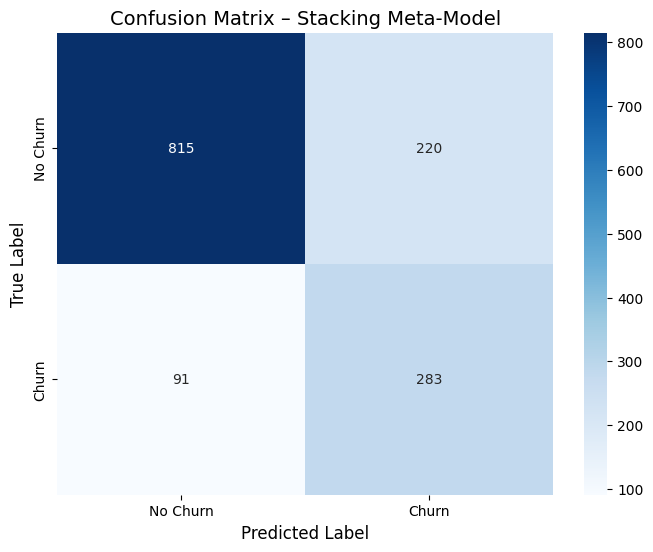

In [ ]:
# Select your best base models (e.g., top 3–4 diverse models)
base_models = [
    ('Logistic Regression', best_models['Logistic Regression']),
    ('AdaBoost', best_models['AdaBoost']),
    ('SVM (RBF)', best_models['SVM (RBF)']),
]

# Meta-model: logistic regression
meta_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=53) # we can also set class_weight={0: 1, 1: 5} which means that missing a churner costs 5× more, the model will work harder to catch churners, even if that means making a few extra false alarms on loyal customers.

# Create stacking classifier
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,                        # 5-fold cross-validation for out-of-fold predictions
    stack_method='predict_proba' # use probabilities, not hard labels
)

# Train the stack on SMOTE-resampled data
stack.fit(x_resampled, y_resampled)

# Evaluate
y_pred_stack = stack.predict(x_test_selected)
print(classification_report(y_test, y_pred_stack))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_stack), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix – Stacking Meta‑Model', fontsize=14)
plt.show()

## 11 Threshold tuning acccording to the business needs

📊 RESULTS FOR MANUAL THRESHOLD = 0.35

📈 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



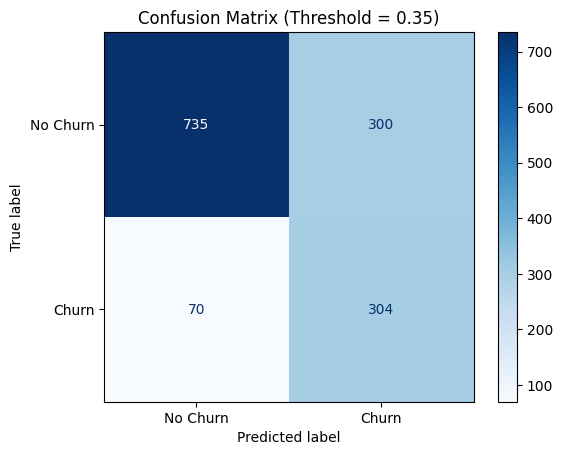


💼 BUSINESS IMPACT SUMMARY
----------------------------------------
✅ Churners caught (True Positives):      304  (21.6%)
❌ Churners missed (False Negatives):      70  (5.0%)
📢 False alarms (False Positives):        300  (21.3%)
😊 Loyal customers left alone (True Negatives):  735  (52.2%)

Out of all actual customers that churned, the model was able to predict 81.3% of them.
Out of all customers the model said that will 'Churn', 50.3% actually churned.


In [ ]:
# 🎛️ MANUAL THRESHOLD SELECTION – YOU CHOOSE THE CUT‑OFF

# Enter any number between 0.0 and 1.0.
# Lower threshold (e.g., 0.3) → higher recall, lower precision.
# Higher threshold (e.g., 0.7) → lower recall, higher precision.
CHOSEN_THRESHOLD = 0.35 

#Get predicted probabilities for the Churn class
y_proba = stack.predict_proba(x_test_selected)[:, 1]

# Apply your chosen threshold
y_pred_manual = (y_proba >= CHOSEN_THRESHOLD).astype(int)

# results
print(f"📊 RESULTS FOR MANUAL THRESHOLD = {CHOSEN_THRESHOLD}")

print("\n📈 Classification Report:")
print(classification_report(y_test, y_pred_manual, target_names=['No Churn', 'Churn']))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_manual,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)
plt.title(f"Confusion Matrix (Threshold = {CHOSEN_THRESHOLD})")
plt.show()

# Business‑friendly counts
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_manual).ravel()
total = tn + fp + fn + tp

print("\n💼 BUSINESS IMPACT SUMMARY")
print("-" * 40)
print(f"✅ Churners caught (True Positives):     {tp:4d}  ({tp/total:.1%})")
print(f"❌ Churners missed (False Negatives):    {fn:4d}  ({fn/total:.1%})")
print(f"📢 False alarms (False Positives):       {fp:4d}  ({fp/total:.1%})")
print(f"😊 Loyal customers left alone (True Negatives): {tn:4d}  ({tn/total:.1%})\n")

recall_churn = recall_score(y_test, y_pred_manual)   
print(f"Out of all actual customers that churned, the model was able to predict {recall_churn:.1%} of them.")

precision_churn = precision_score(y_test, y_pred_manual)
print(f"Out of all customers the model said that will 'Churn', {precision_churn:.1%} actually churned.")